# Heart Disease 분류 모델링

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, accuracy_score
)

## 데이터 로드

In [29]:
# 로지스틱회귀용: 스케일링 적용본
train_scaled = pd.read_csv('dataset/heart_train_scaled.csv')
test_scaled = pd.read_csv('dataset/heart_test_scaled.csv')
X_train_lr = train_scaled.drop('HeartDisease', axis=1)
y_train_lr = train_scaled['HeartDisease']
X_test_lr = test_scaled.drop('HeartDisease', axis=1)
y_test_lr = test_scaled['HeartDisease']

# 랜덤포레스트용: 스케일링 안 한 원본(인코딩만 된 상태)
train_raw = pd.read_csv('dataset/heart_train.csv')
test_raw = pd.read_csv('dataset/heart_test.csv')
X_train_rf = train_raw.drop('HeartDisease', axis=1)
y_train_rf = train_raw['HeartDisease']
X_test_rf = test_raw.drop('HeartDisease', axis=1)
y_test_rf = test_raw['HeartDisease']

print(X_train_lr.shape, X_test_lr.shape, X_train_rf.shape, X_test_rf.shape)

(733, 15) (184, 15) (733, 15) (184, 15)


## 1. Logistic Regression (해석용 베이스라인)

In [30]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_lr, y_train_lr)

y_pred_lr = log_reg.predict(X_test_lr)
y_proba_lr = log_reg.predict_proba(X_test_lr)[:, 1]

print(classification_report(y_test_lr, y_pred_lr))
print('ROC-AUC:', roc_auc_score(y_test_lr, y_proba_lr))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85        72
           1       0.92      0.88      0.90       112

    accuracy                           0.88       184
   macro avg       0.87      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184

ROC-AUC: 0.9203869047619047


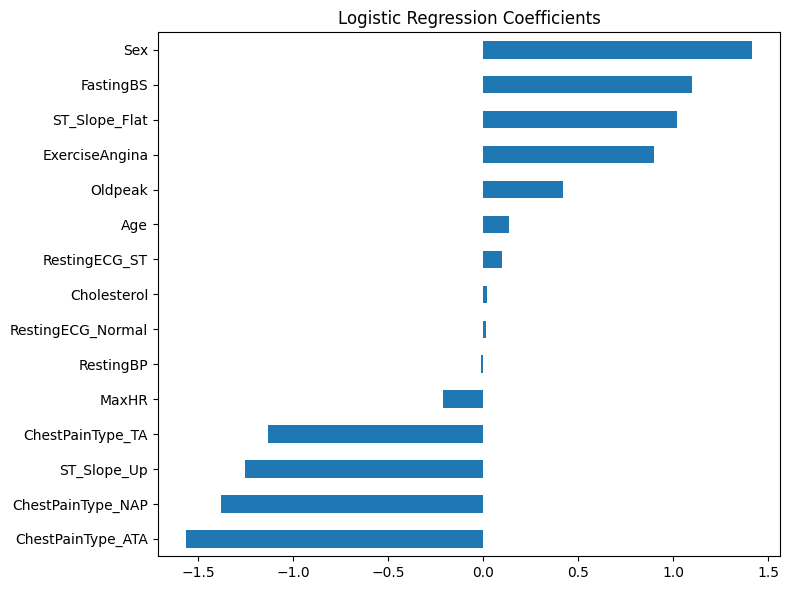

In [31]:
# 회귀 계수로 변수별 영향 방향/크기 확인
coef_df = pd.Series(log_reg.coef_[0], index=X_train_lr.columns).sort_values()

plt.figure(figsize=(8, 6))
coef_df.plot(kind='barh')
plt.title('Logistic Regression Coefficients')
plt.tight_layout()
plt.savefig('output/heart-figures/logreg_coefficients.png', dpi=120)
plt.show()

## 1-1. 스케일러 비교 (Logistic Regression)
전처리 단계에서 StandardScaler, MinMaxScaler, RobustScaler 3종으로 변환한 데이터를 모두 저장해두었다. 어떤 스케일러가 로지스틱회귀 성능에 가장 적합한지 비교한다.

In [32]:
# 스케일러별 데이터로 로지스틱회귀를 각각 학습시켜 Accuracy/ROC-AUC 비교
scaler_files = {
    'StandardScaler': ('dataset/heart_train_scaled.csv', 'dataset/heart_test_scaled.csv'),
    'MinMaxScaler': ('dataset/heart_train_minmax.csv', 'dataset/heart_test_minmax.csv'),
    'RobustScaler': ('dataset/heart_train_robust.csv', 'dataset/heart_test_robust.csv'),
}

scaler_lr_results = {}
for name, (train_path, test_path) in scaler_files.items():
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    X_tr = train.drop('HeartDisease', axis=1)
    y_tr = train['HeartDisease']
    X_te = test.drop('HeartDisease', axis=1)
    y_te = test['HeartDisease']

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]

    scaler_lr_results[name] = {
        'Accuracy': accuracy_score(y_te, pred),
        'ROC-AUC': roc_auc_score(y_te, proba),
    }

scaler_comparison = pd.DataFrame(scaler_lr_results).T.sort_values('ROC-AUC', ascending=False)
print(scaler_comparison)

                Accuracy   ROC-AUC
MinMaxScaler    0.875000  0.921751
StandardScaler  0.880435  0.920387
RobustScaler    0.880435  0.920387


## 2. Random Forest (성능용)

In [33]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_rf, y_train_rf)

y_pred_rf = rf.predict(X_test_rf)
y_proba_rf = rf.predict_proba(X_test_rf)[:, 1]

print(classification_report(y_test_rf, y_pred_rf))
print('ROC-AUC:', roc_auc_score(y_test_rf, y_proba_rf))

              precision    recall  f1-score   support

           0       0.86      0.83      0.85        72
           1       0.89      0.91      0.90       112

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184

ROC-AUC: 0.9293774801587302


In [34]:
# 하이퍼파라미터 튜닝
param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [4, 8, 12, None],
    'max_features': ['sqrt', 'log2'],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
)
grid_search.fit(X_train_rf, y_train_rf)

print('Best params:', grid_search.best_params_)
rf_best = grid_search.best_estimator_

y_pred_rf_best = rf_best.predict(X_test_rf)
y_proba_rf_best = rf_best.predict_proba(X_test_rf)[:, 1]

print(classification_report(y_test_rf, y_pred_rf_best))
print('ROC-AUC:', roc_auc_score(y_test_rf, y_proba_rf_best))

Best params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.86      0.83      0.85        72
           1       0.89      0.91      0.90       112

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184

ROC-AUC: 0.9293774801587302


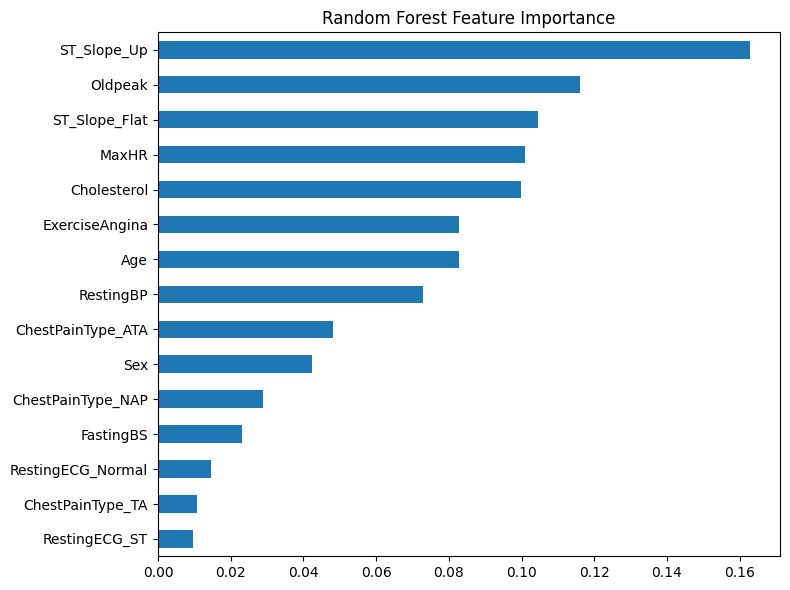

In [35]:
importance = pd.Series(rf_best.feature_importances_, index=X_train_rf.columns).sort_values()

plt.figure(figsize=(8, 6))
importance.plot(kind='barh')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig('output/heart-figures/rf_feature_importance.png', dpi=120)
plt.show()

## 3. Boosting 계열 모델 (GradientBoosting / XGBoost / LightGBM)

In [36]:
# 하이퍼파라미터 튜닝 (모델별 param_grid + GridSearchCV)
boosting_configs = {
    'GradientBoosting': (
        GradientBoostingClassifier(random_state=42),
        {
            'n_estimators': [100, 200, 400],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [2, 3, 4],
        },
    ),
    'XGBoost': (
        XGBClassifier(eval_metric='logloss', random_state=42),
        {
            'n_estimators': [100, 200, 400],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 4, 6],
            'subsample': [0.8, 1.0],
        },
    ),
    'LightGBM': (
        LGBMClassifier(random_state=42, verbosity=-1),
        {
            'n_estimators': [100, 200, 400],
            'learning_rate': [0.01, 0.05, 0.1],
            'num_leaves': [15, 31, 63],
        },
    ),
}

boosting_results = {}

for name, (estimator, param_grid) in boosting_configs.items():
    grid_search = GridSearchCV(
        estimator,
        param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
    )
    grid_search.fit(X_train_rf, y_train_rf)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_rf)
    y_proba = best_model.predict_proba(X_test_rf)[:, 1]
    boosting_results[name] = {
        'model': best_model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'Accuracy': accuracy_score(y_test_rf, y_pred),
        'ROC-AUC': roc_auc_score(y_test_rf, y_proba),
    }
    print(f'--- {name} ---')
    print('Best params:', grid_search.best_params_)
    print(classification_report(y_test_rf, y_pred))
    print('ROC-AUC:', boosting_results[name]['ROC-AUC'])
    print()

--- GradientBoosting ---
Best params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.87      0.86      0.87        72
           1       0.91      0.92      0.92       112

    accuracy                           0.90       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.90      0.90      0.90       184

ROC-AUC: 0.9455605158730158

--- XGBoost ---
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
              precision    recall  f1-score   support

           0       0.87      0.83      0.85        72
           1       0.90      0.92      0.91       112

    accuracy                           0.89       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184

ROC-AUC: 0.9465525793650793

--- LightGBM ---
Best params: {'learning_rate': 0.05, 'n_estimators': 100, 'num_le

## 4. 모델 비교

In [37]:
comparison = pd.DataFrame({
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test_lr, y_pred_lr),
        'ROC-AUC': roc_auc_score(y_test_lr, y_proba_lr),
    },
    'Random Forest (tuned)': {
        'Accuracy': accuracy_score(y_test_rf, y_pred_rf_best),
        'ROC-AUC': roc_auc_score(y_test_rf, y_proba_rf_best),
    },
    **{
        name: {'Accuracy': res['Accuracy'], 'ROC-AUC': res['ROC-AUC']}
        for name, res in boosting_results.items()
    },
}).T.sort_values('ROC-AUC', ascending=False)

comparison

,Accuracy,ROC-AUC
LightGBM,0.875000,0.947049
XGBoost,0.885870,0.946553
GradientBoosting,0.896739,0.945561
Random Forest (tuned),0.880435,0.929377
Logistic Regression,0.880435,0.920387


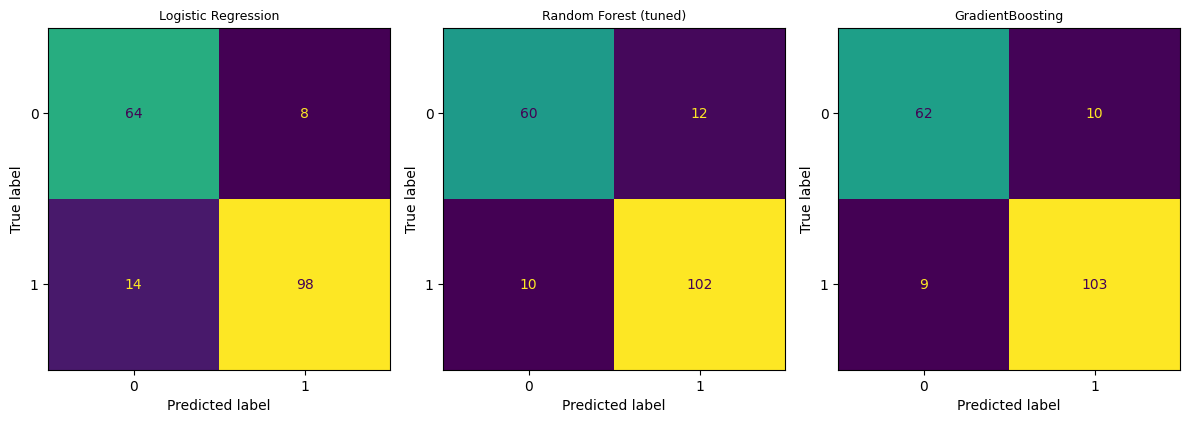

In [38]:
selected_models = ['Logistic Regression', 'Random Forest (tuned)', 'GradientBoosting']
all_preds = {
    'Logistic Regression': y_pred_lr,
    'Random Forest (tuned)': y_pred_rf_best,
    'GradientBoosting': boosting_results['GradientBoosting']['y_pred'],
}
all_true = {
    'Logistic Regression': y_test_lr,
    'Random Forest (tuned)': y_test_rf,
    'GradientBoosting': y_test_rf,
}

fig, axes = plt.subplots(1, len(selected_models), figsize=(4 * len(selected_models), 4))
for ax, name in zip(axes, selected_models):
    ConfusionMatrixDisplay.from_predictions(all_true[name], all_preds[name], ax=ax, colorbar=False)
    ax.set_title(name, fontsize=9)
plt.tight_layout()
plt.savefig('output/heart-figures/confusion_matrices.png', dpi=120)
plt.show()

## 5. 최종 모델(GradientBoosting) 상세 분석

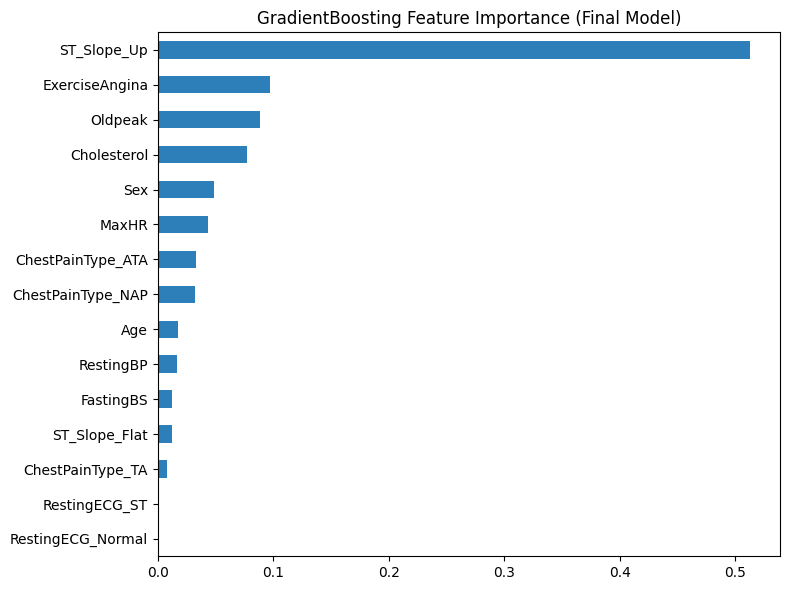

In [39]:
# 최종 채택 모델(GradientBoosting, 임상 목적상 누락/과잉검사 균형이 가장 우수)의 변수 중요도
gb_best = boosting_results['GradientBoosting']['model']
gb_importance = pd.Series(gb_best.feature_importances_, index=X_train_rf.columns).sort_values()

plt.figure(figsize=(8, 6))
gb_importance.plot(kind='barh', color='#2c7fb8')
plt.title('GradientBoosting Feature Importance (Final Model)')
plt.tight_layout()
plt.savefig('output/heart-figures/gb_feature_importance.png', dpi=120)
plt.show()

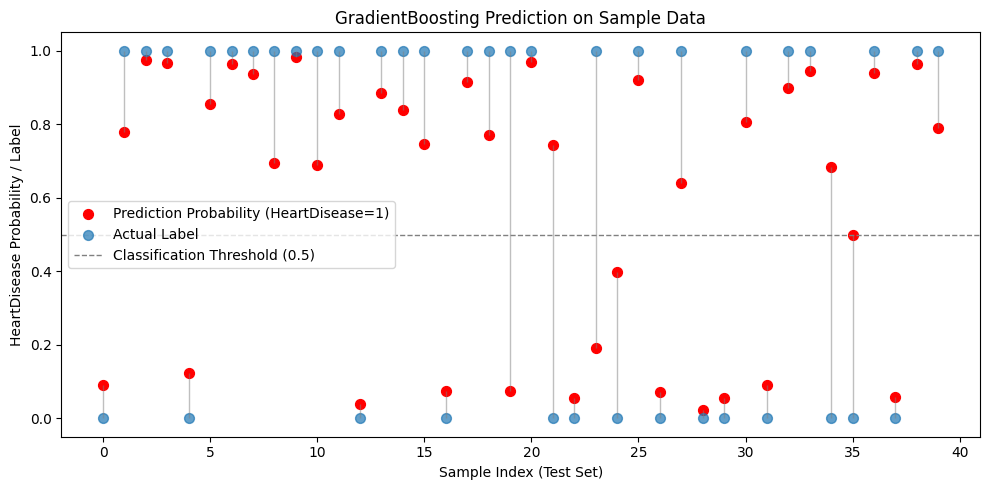

In [40]:
# 테스트셋 샘플 데이터를 통한 예측 결과 (실제 라벨 vs 예측 확률)
sample_n = 40
sample_idx = np.arange(sample_n)
sample_actual = y_test_rf.values[:sample_n]
sample_proba = boosting_results['GradientBoosting']['y_proba'][:sample_n]

plt.figure(figsize=(10, 5))
plt.scatter(sample_idx, sample_proba, color='red', s=50, alpha=1.0, label='Prediction Probability (HeartDisease=1)')
plt.scatter(sample_idx, sample_actual, color='tab:blue', s=50, alpha=0.7, label='Actual Label')
plt.vlines(sample_idx, sample_actual, sample_proba, color='gray', linewidth=1, alpha=0.5, zorder=1)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Classification Threshold (0.5)')
plt.xlabel('Sample Index (Test Set)')
plt.ylabel('HeartDisease Probability / Label')
plt.title('GradientBoosting Prediction on Sample Data')
plt.legend()
plt.tight_layout()
plt.savefig('output/heart-figures/gb_sample_prediction.png', dpi=120)
plt.show()

## 6. 임의 테스트 데이터로 예측해보기

In [41]:
# 임의로 작성한 환자 데이터(원본 컬럼 형식)를 전처리와 동일한 방식으로 인코딩한 뒤
# 최종 채택 모델(GradientBoosting)로 HeartDisease 예측
new_patients = pd.DataFrame([
    {
        'Age': 58, 'Sex': 'M', 'ChestPainType': 'ASY', 'RestingBP': 145,
        'Cholesterol': 270, 'FastingBS': 1, 'RestingECG': 'ST', 'MaxHR': 120,
        'ExerciseAngina': 'Y', 'Oldpeak': 2.1, 'ST_Slope': 'Flat',
    },
    {
        'Age': 35, 'Sex': 'F', 'ChestPainType': 'ATA', 'RestingBP': 110,
        'Cholesterol': 180, 'FastingBS': 0, 'RestingECG': 'Normal', 'MaxHR': 175,
        'ExerciseAngina': 'N', 'Oldpeak': 0.0, 'ST_Slope': 'Up',
    },
])

# heart_preprocessing.ipynb와 동일한 인코딩 규칙 적용
new_patients_encoded = new_patients.copy()
new_patients_encoded['Sex'] = new_patients_encoded['Sex'].map({'M': 1, 'F': 0})
new_patients_encoded['ExerciseAngina'] = new_patients_encoded['ExerciseAngina'].map({'Y': 1, 'N': 0})
new_patients_encoded = pd.get_dummies(
    new_patients_encoded, columns=['ChestPainType', 'RestingECG', 'ST_Slope'],
    drop_first=True, dtype=int,
)

# 학습 시 사용된 컬럼 구성과 동일하게 맞춤 (없는 더미 컬럼은 0으로 채움)
new_patients_encoded = new_patients_encoded.reindex(columns=X_train_rf.columns, fill_value=0)

new_pred = gb_best.predict(new_patients_encoded)
new_proba = gb_best.predict_proba(new_patients_encoded)[:, 1]

result = new_patients.copy()
result['Predicted_HeartDisease'] = new_pred
result['Predicted_Probability'] = new_proba.round(4)
result

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,Predicted_HeartDisease,Predicted_Probability
0,58,M,ASY,145,270,1,ST,120,Y,2.1,Flat,1,0.9393
1,35,F,ATA,110,180,0,Normal,175,N,0.0,Up,0,0.0504
